# Posterior screening of hundreds of stocks

In [ ]:
import numpy as np
import pandas as pd

import bayesflow as bf
import keras


from pathlib import Path
from time import perf_counter
from IPython.display import display

from mmar import screener
from mmar.screener import screen, viz

In [2]:
MODEL_PATH = Path("checkpoints/univariate/model.keras")
AS_OF = (pd.Timestamp.now(tz="UTC") - pd.Timedelta(days=1)).date()
FIGURES = Path("figures/screener")
FIGURES.mkdir(parents=True, exist_ok=True)
N_STOCKS = 500
RULE = screener.Rule(round_trip_cost=0.002)

## 1 Load the pretrained neural estimator

In [4]:
approximator = keras.saving.load_model(MODEL_PATH)

## 2 The whole market is a batch

- Use the latest 256 daily returns for up to 500 S&P stocks.
- Keep complete histories and select stocks alphabetically.
- The table below counts usable histories and exclusions.

[Membership data](https://github.com/datasets/s-and-p-500-companies) and adjusted Yahoo Finance prices are cached in `data/screener/`.

In [5]:
members = screener.load_universe()
prices = screener.load_prices(members, AS_OF)
series, metadata, dates, universe_audit = screener.stock_windows(
    prices, members, AS_OF, n_stocks=N_STOCKS
    
)

print(f"Raw input: {series.shape} = (stocks, time, channel)")
print(f"Membership snapshot: {members.membership_snapshot.iloc[0]}; last close: {dates[-1].date()}")
display(universe_audit.status.value_counts().rename("stocks").to_frame())
universe_audit.to_csv(FIGURES / "universe_audit.csv", index=False)

Raw input: (499, 256, 1) = (stocks, time, channel)
Membership snapshot: 2026-09-06; last close: 2026-09-04


,stocks
status,
screened,499
missing/invalid price history,4


### Return histories

Each row is a stock and each column is a trading day. The colors show daily returns in percent. All rows go through the same trained model.

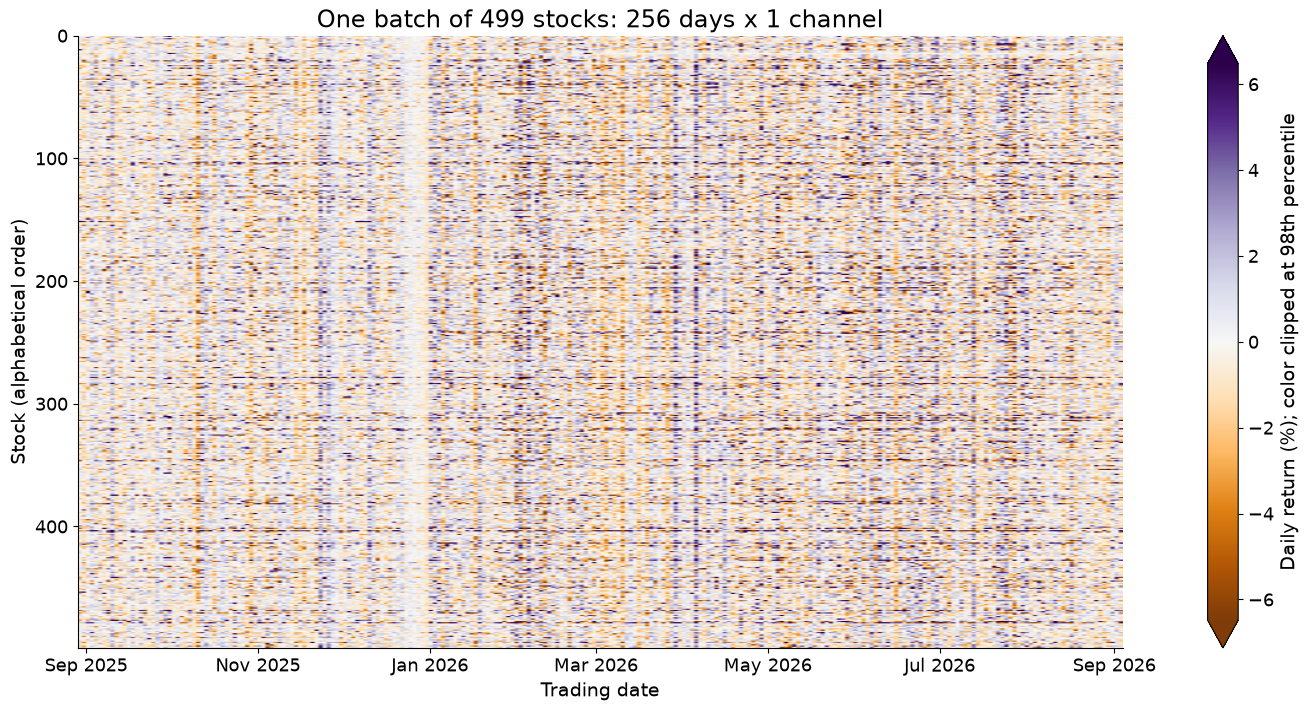

In [6]:
viz.batch_plot(series, dates, FIGURES / "01_stock_batch.png")

## 3 Amortized deployment

One call, internally minibatched. Timing below measures posterior inference.

In [8]:
posterior, real_summaries, inference_seconds = screener.infer_parameters(
    approximator, series, 
    num_samples=512, 
    batch_size=64,
    seed=42
)
print(f"Posterior: {posterior.shape} = (stocks, draws, parameters)")
print(f"Learned summaries: {real_summaries.shape} = (stocks, embedding dimensions)")
print(f"{inference_seconds:.2f}s total; {1000 * inference_seconds / len(series):.1f} ms/stock")

Summarizing:   0%|          | 0/8 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/8 [00:00<?, ?batch/s]

Posterior: (499, 512, 4) = (stocks, draws, parameters)
Learned summaries: (499, 16) = (stocks, embedding dimensions)
0.50s total; 1.0 ms/stock


### Learned summary space: simulations versus real returns

The pretrained summary network maps prior-predictive return paths and the 499 observed return windows into the same 16-dimensional space. After standardizing each coordinate across the combined batch, we can fit a single UMAP to all summary vectors, so neighborhood overlap is visually comparable. This is a descriptive model-coverage check.

Summarizing:   0%|          | 0/32 [00:00<?, ?batch/s]

/home/radevs/anaconda3/envs/bfjax/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


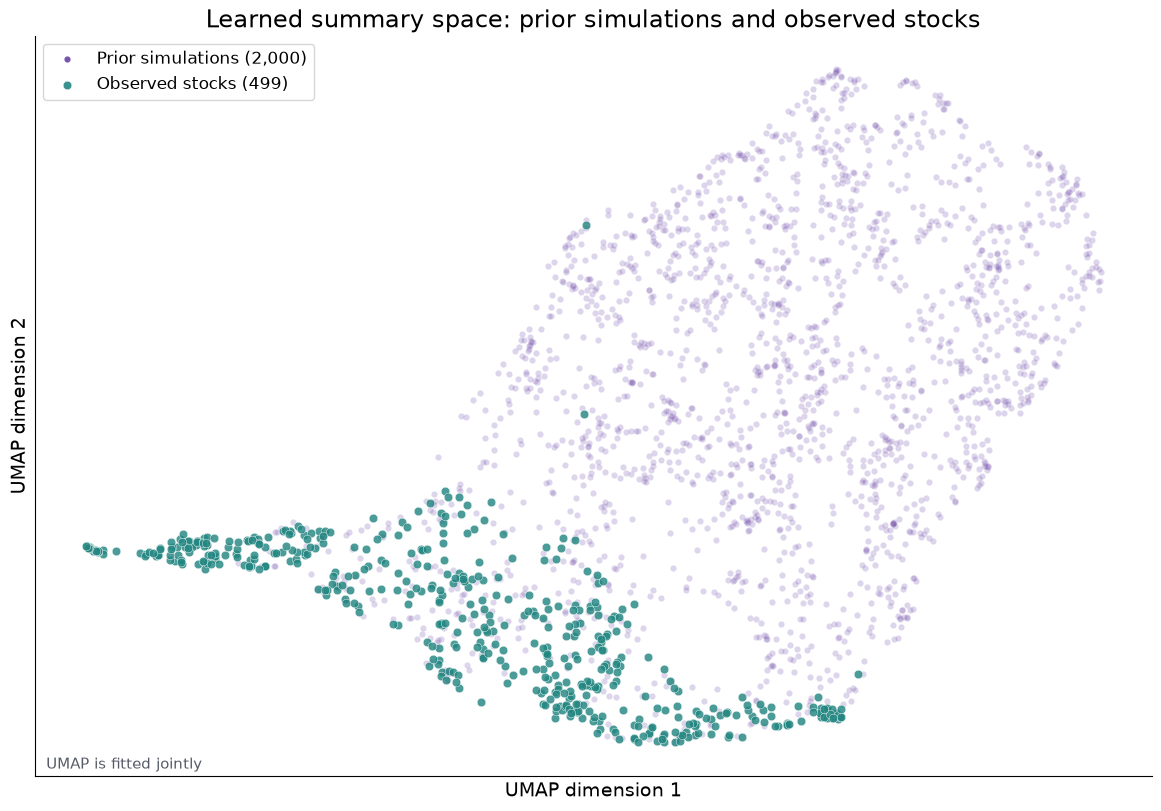

In [9]:
simulated_summaries = screener.prior_summary_embeddings(
    approximator, n_simulations=2_000, batch_size=64, seed=44
)
viz.embedding_space_plot(
    simulated_summaries,
    real_summaries,
    labels=("Prior simulations", "Observed stocks"),
    path=FIGURES / "02_summary_embedding_umap.png",
    seed=44,
)

## 4 Rank by gain probability per unit of risk

- **Gain probability:** the likelihood that the next 20-day return covers the 0.20% trading cost.
- **Expected shortfall (ES):** the average gross loss in the worst 5% of simulated 20-day outcomes.
- **Score:** `gain probability (%) / ES (%)`. For example, `70 / 10 = 7`. Higher values combine a greater likelihood of gain with less downside.

In [10]:
risk_start = perf_counter()
ranking, coverage_checks = screener.screen_stocks(
    posterior, 
    series, 
    metadata, 
    rule=RULE,
    n_parameter_draws=64, 
    n_replications=512, 
    n_ppc=512, 
    seed=43,
)

risk_seconds = perf_counter() - risk_start
ranking.to_csv(FIGURES / "stock_screen.csv", index=False)
coverage_checks.to_csv(FIGURES / "coverage_checks.csv", index=False)

pd.DataFrame({
    "stage": ["Posterior inference", "Risk simulation + predictive checks"],
    "seconds": [inference_seconds, risk_seconds],
    "stocks": [len(series), len(series)],
}).to_csv(FIGURES / "deployment_timing.csv", index=False)
print(f"Ranked {len(ranking)} stocks in {risk_seconds:.1f}s.")

Risk + PPC: 25/499 stocks (7.3s)
Risk + PPC: 50/499 stocks (14.6s)
Risk + PPC: 75/499 stocks (21.9s)
Risk + PPC: 100/499 stocks (29.2s)
Risk + PPC: 125/499 stocks (36.6s)
Risk + PPC: 150/499 stocks (43.9s)
Risk + PPC: 175/499 stocks (51.1s)
Risk + PPC: 200/499 stocks (58.4s)
Risk + PPC: 225/499 stocks (65.6s)
Risk + PPC: 250/499 stocks (73.0s)
Risk + PPC: 275/499 stocks (80.2s)
Risk + PPC: 300/499 stocks (87.5s)
Risk + PPC: 325/499 stocks (94.8s)
Risk + PPC: 350/499 stocks (102.0s)
Risk + PPC: 375/499 stocks (109.3s)
Risk + PPC: 400/499 stocks (116.6s)
Risk + PPC: 425/499 stocks (123.8s)
Risk + PPC: 450/499 stocks (131.1s)
Risk + PPC: 475/499 stocks (138.5s)
Risk + PPC: 499/499 stocks (145.6s)
Ranked 499 stocks in 145.7s.


### Gain probability and downside

- Left: gain probability against 20-day expected shortfall.
- Right: a forest plot of the top 12. Each dot is the gain/ES score; the line shows its 90% posterior interval.

The colors warn about possible model mismatch. We compare each stock's mean, volatility, return tails and maximum drawdown with 99% prior and posterior predictive ranges. We also flag scale estimates concentrated at the prior limits. Purple means these checks passed; grey means at least one warning. These are rough diagnostics, and every stock keeps its rank.

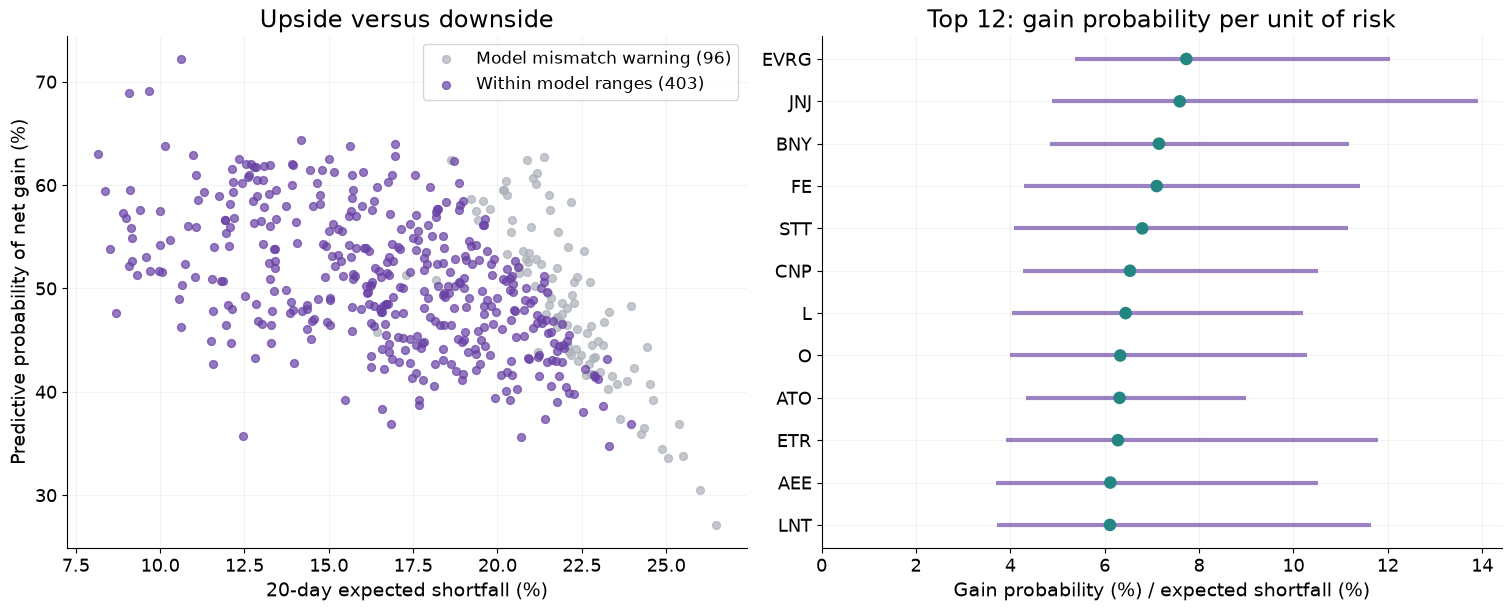

In [11]:
viz.opportunity_plot(ranking, FIGURES / "02_opportunities.png")

### Top five stocks

The table is sorted by gain/ES. Gain probability includes trading costs. `coverage_ok` is true when none of the model-mismatch checks raised a warning.

In [12]:
columns = [
    "rank", "ticker", "sector", "gain_to_es", "predictive_gain_probability",
    "predictive_es95_pct", "es95_posterior_q05_pct", "es95_posterior_q95_pct",
    "coverage_ok",
]

display(ranking[columns].head(5).style.format({"predictive_gain_probability": "{:.1%}"}, precision=2))

,rank,ticker,sector,gain_to_es,predictive_gain_probability,predictive_es95_pct,es95_posterior_q05_pct,es95_posterior_q95_pct,coverage_ok
0,1,EVRG,Utilities,7.73,63.0%,8.15,6.00,9.58,True
1,2,JNJ,Health Care,7.59,68.9%,9.08,5.76,11.22,True
2,3,BNY,Financials,7.15,69.1%,9.66,7.09,11.96,True
3,4,FE,Utilities,7.10,59.5%,8.37,6.41,10.52,True
4,5,STT,Financials,6.80,72.2%,10.62,7.19,13.11,True


### Parameter estimates

For the top 12 stocks, dots mark posterior medians and lines cover the central 90% of draws. Drift and scale are shown in percent.

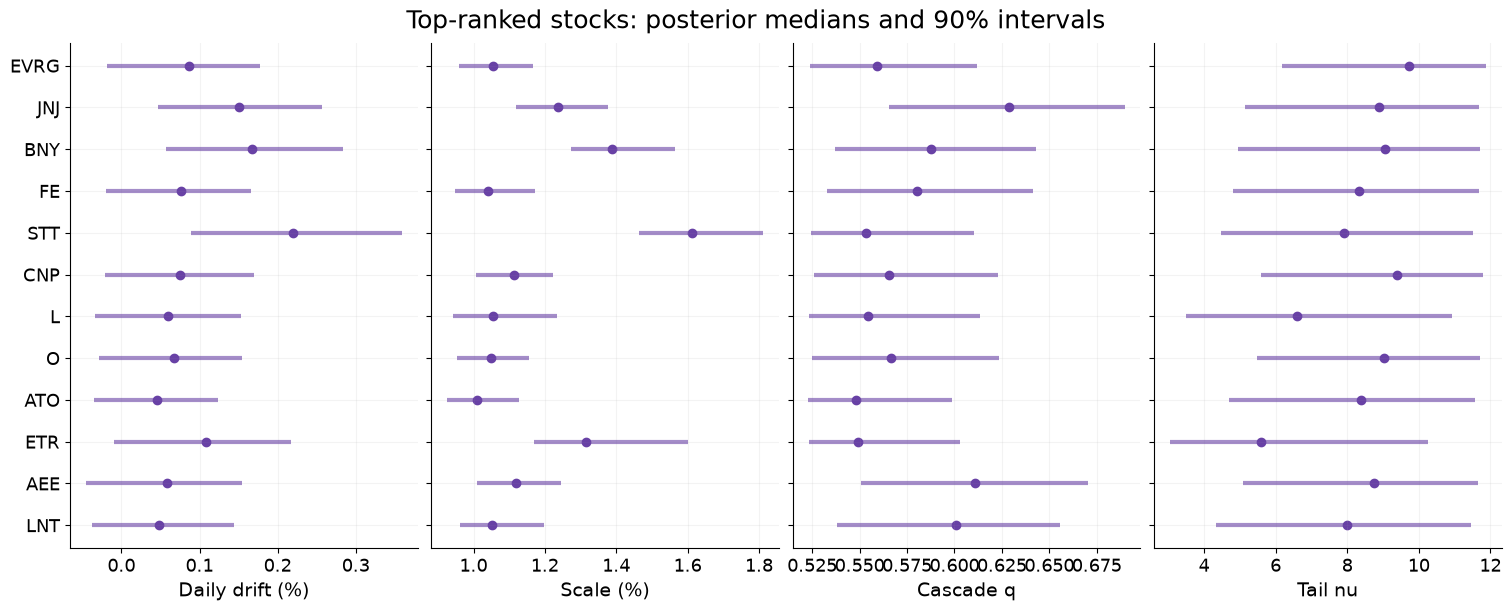

In [13]:
viz.parameter_plot(ranking, FIGURES / "03_parameter_posteriors.png")

## 5 Check the four highest-ranked stocks

Each row is one of the four highest-ranked stocks, and each posterior draw generates one 256-day return path.

- **Wealth:** observed growth in black dashes, the predictive median in purple, and 68% and 92% predictive intervals.
- **Daily returns:** observed and simulated histograms, with the predictive median marked.
- **Maximum drawdown:** one value per simulated path. The black dashed line marks the observed loss; purple marks the predictive median.

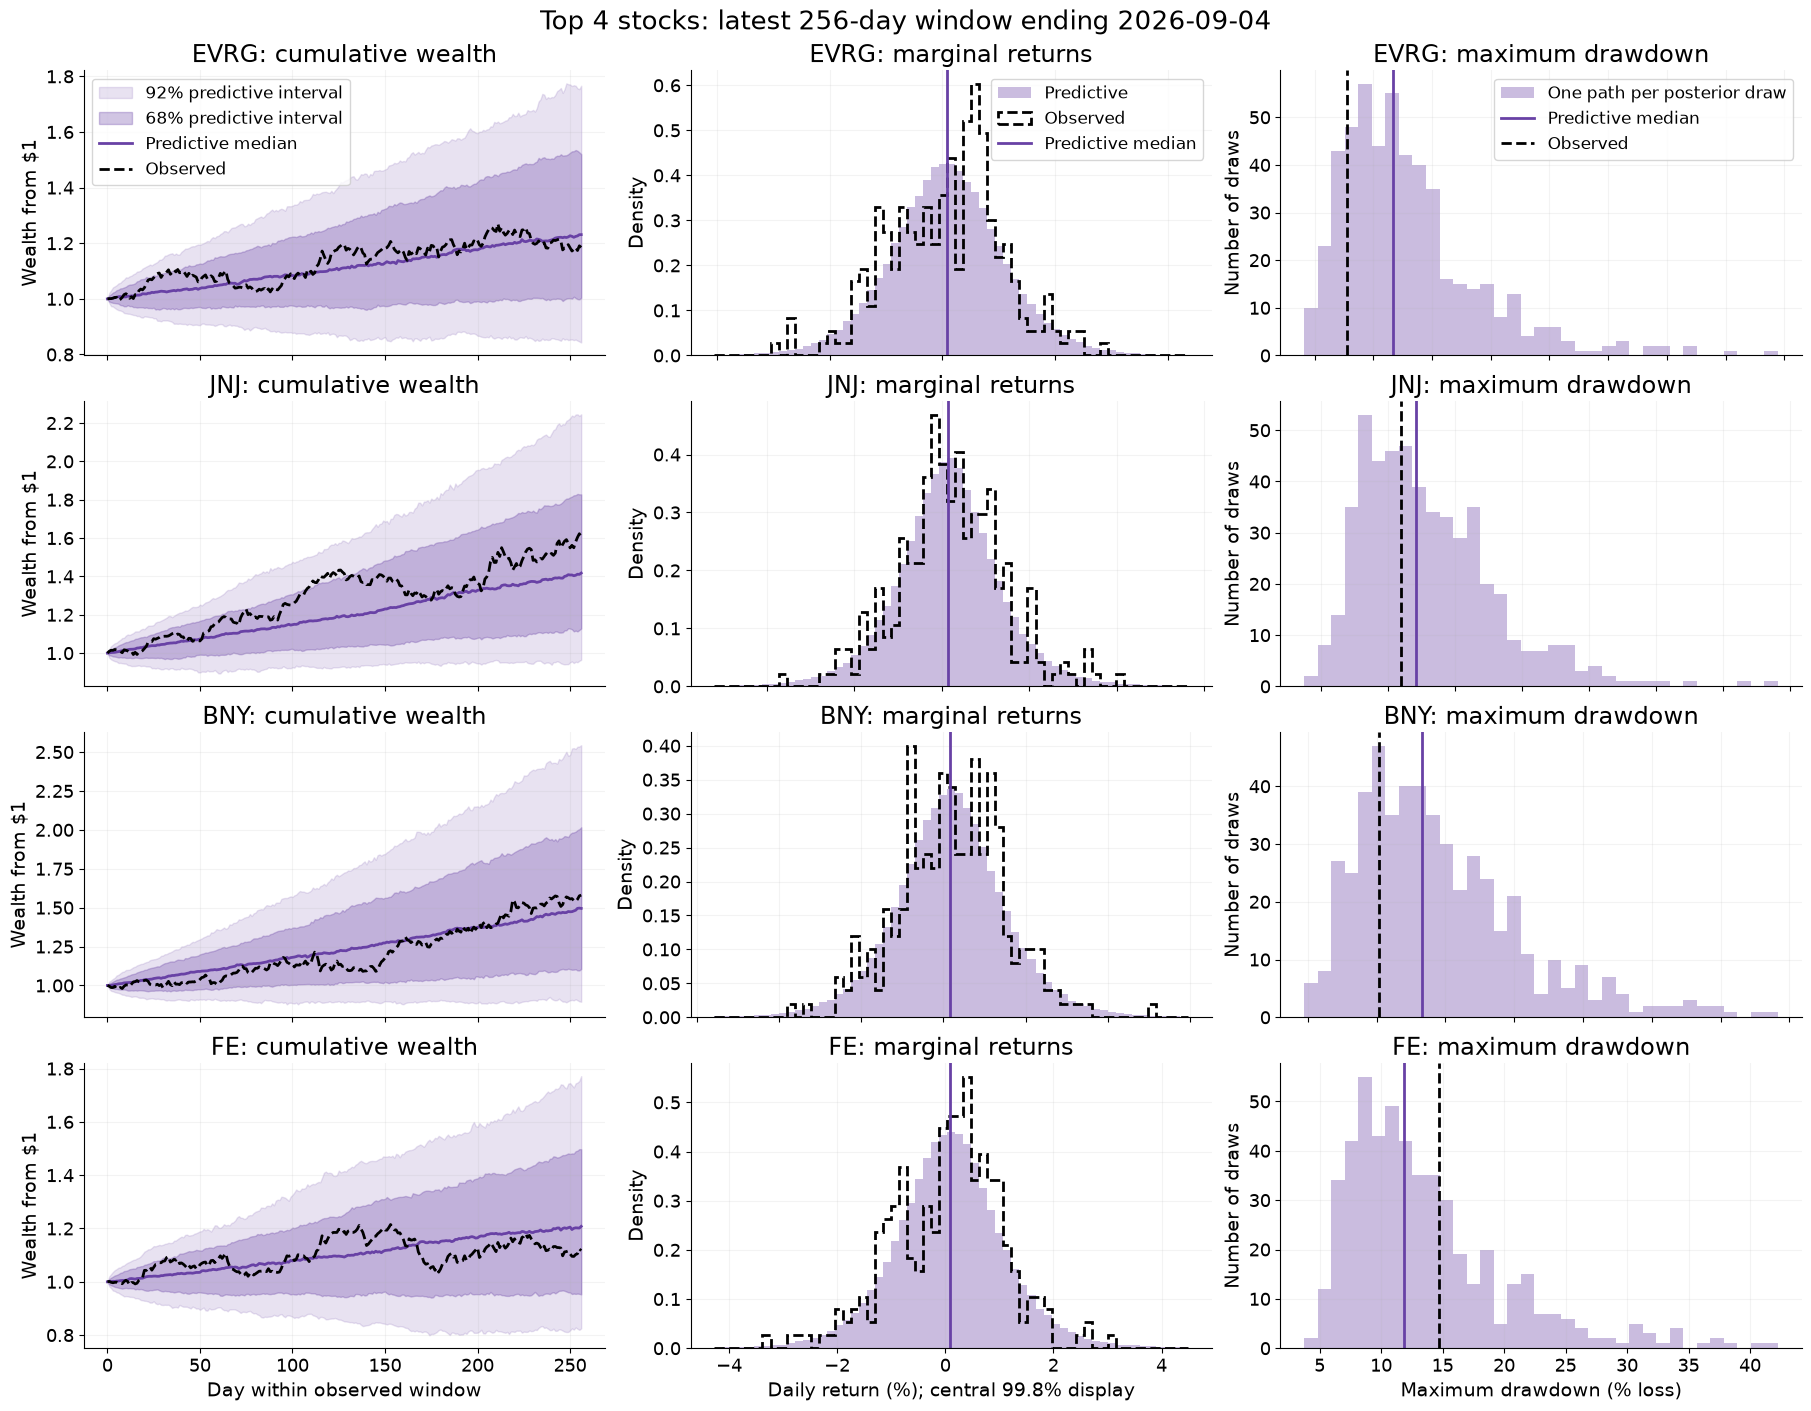

: 

In [ ]:
viz.fit_plot(
    posterior, series, metadata, ranking, dates,
    FIGURES / "04_leading_stock_fit.png", top_n=4, figsize=(18, 14)
)